# Non-Parametric Regression: modeling without a fixed equation

## 1. Theoretical Foundation

### 1.1 The Philosophy
In the previous modules (Linear, Robust), we imposed a **structure** on the world. We said: "The relationship is a line ($y=mx+b$)."
*   **Pros:** If the world IS a line, this is efficient and accurate.
*   **Cons:** If the world is a complex, wobbly curve, our model is fundamentally wrong (High Bias).

**Non-Parametric Regression** flips the script. It assumes **zero structure**. It says: "I don't know the formula. I will just look at the history."
*   **Mechanism:** To predict $y$ for a new query $x$, the model looks for training examples close to $x$ and interpolates their values.
*   **The Trade-off:** We trade **Assumption** (Bias) for **Data Dependence** (Variance). These models need *lots* of data to cover the space effectively.

### 1.2 The Evolution
All these methods are based on one principle: **Similarity**.
1.  **KNN:** "Who are my neighbors?" (Discrete Sets).
2.  **Kernel Regression:** "How close is everyone?" (Continuous Weighting).
3.  **Gaussian Processes:** "How correlated are we?" (Probabilistic Covariance).

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set aesthetics
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 15

## 2. Data Preparation: The California Housing Dataset

Non-parametric methods excel in **spatial** contexts where "closeness" has a physical meaning. The California Housing dataset is ideal because house prices are heavily driven by location (Latitude/Longitude), a relationship that is complex, non-linear, and geographically clustered.

We will use a subset of 2,000 samples to ensure our scratch implementations (which can be $O(N^2)$) run efficiently.

Baseline RMSE (Mean Prediction): 1.1845


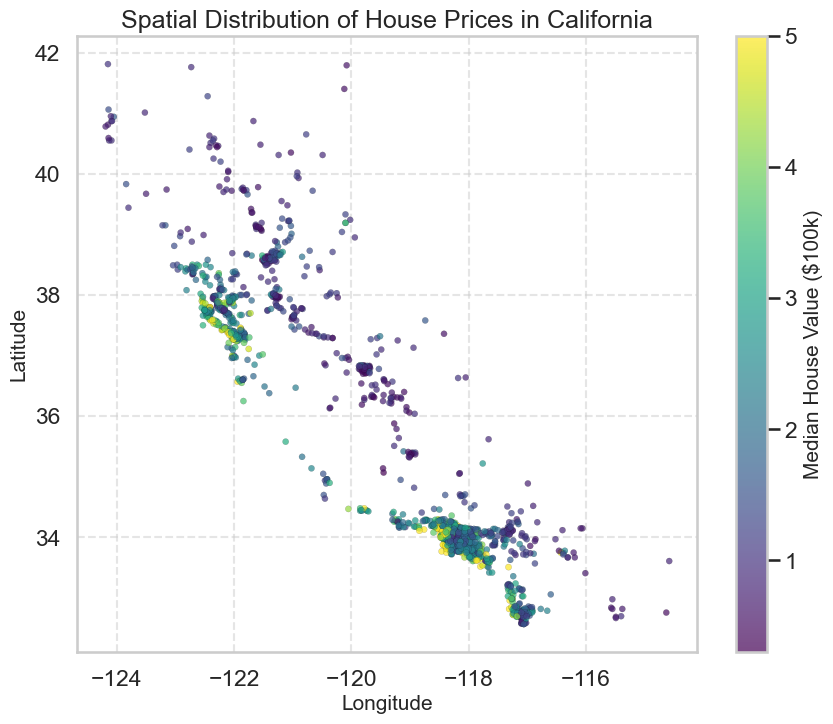

In [27]:
# 1. Load Data
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Price'] = california.target

# 2. Subsample for efficiency
df_sample = df.sample(n=2000, random_state=42)

# We focus ONLY on Location (Lat/Lon) to visualize the 2D regression surface
X = df_sample[['Longitude', 'Latitude']].values
y = df_sample['Price'].values

# Split for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualization
plt.figure(figsize=(10, 8))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=20, alpha=0.7, edgecolor='k', linewidth=0.1)
plt.colorbar(label='Median House Value ($100k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title("Spatial Distribution of House Prices in California", fontsize=18)
plt.grid(True, linestyle='--', alpha=0.5);

# Baseline Metric (Predicting the Mean)
baseline_preds = np.full_like(y_test, np.mean(y_train))
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print(f"Baseline RMSE (Mean Prediction): {baseline_rmse:.4f}")

## 3. K-Nearest Neighbors (KNN)

### 3.1 The Intuition
KNN is the "common sense" algorithm. If you want to know the price of a house, you don't build a complex economic theory. You just look at the 5 nearest houses sold recently and average them.

### 3.2 The Hyperparameter: K
*   **Small K (e.g., K=1):** The model is "Hyper-Reactive". It connects the dots perfectly. If one house is an outlier, the prediction spikes. High Variance, Low Bias.
*   **Large K (e.g., K=100):** The model is "Conservative". It averages so many points that it smooths out all details, eventually becoming a flat line (the global average). Low Variance, High Bias.

### 3.3 The Refinement: Weighted Voting
Standard KNN treats a neighbor 10 meters away the same as one 500 meters away. They both get 1 vote.
**Weighted KNN** corrects this injustice. It says: "Distance = Authority".
*   **Weight Formula:** $w_i = \frac{1}{d(x_q, x_i)}$
*   A neighbor at distance 0.1 gets weight 10.
*   A neighbor at distance 10 gets weight 0.1.
This allows us to use a larger $K$ (to get stability) without losing the precision of the closest points.

KNN Uniform (K=10) RMSE:  0.7213
KNN Weighted (K=10) RMSE: 0.6682
Improvement from Weighting: 7.36%


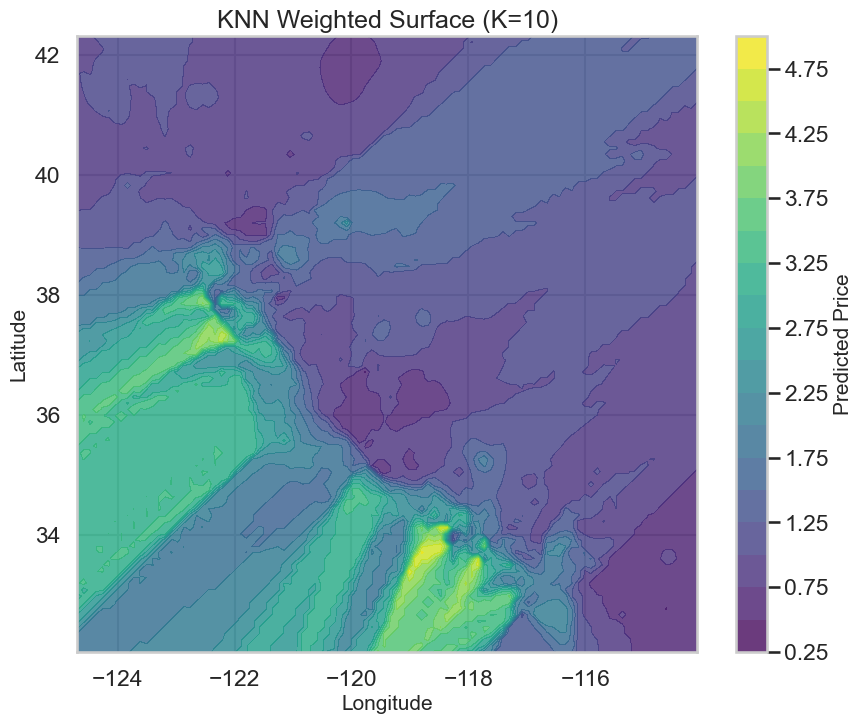

In [28]:
class ScratchKNN:
    def __init__(self, k=5, weights='uniform'):
        self.k = k
        self.weights = weights
        self.X_train = None
        self.y_train = None
        
    def fit(self, X, y):
        # Lazy Learning
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        
    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = []
        
        for x_query in X_test:
            # 1. Distances
            dists = np.sqrt(np.sum((self.X_train - x_query)**2, axis=1))
            
            # 2. Get Top K
            k_indices = np.argsort(dists)[:self.k]
            k_dists = dists[k_indices]
            k_labels = self.y_train[k_indices]
            
            # 3. Aggregate
            if self.weights == 'uniform':
                pred = np.mean(k_labels)
            elif self.weights == 'distance':
                # Avoid division by zero
                k_dists = np.maximum(k_dists, 1e-10) 
                w = 1 / k_dists
                pred = np.sum(w * k_labels) / np.sum(w)
            
            predictions.append(pred)
            
        return np.array(predictions)

# Comparing Uniform vs Weighted
knn_u = ScratchKNN(k=10, weights='uniform')
knn_u.fit(X_train, y_train)
rmse_u = np.sqrt(mean_squared_error(y_test, knn_u.predict(X_test)))

knn_w = ScratchKNN(k=10, weights='distance')
knn_w.fit(X_train, y_train)
rmse_w = np.sqrt(mean_squared_error(y_test, knn_w.predict(X_test)))

print(f"KNN Uniform (K=10) RMSE:  {rmse_u:.4f}")
print(f"KNN Weighted (K=10) RMSE: {rmse_w:.4f}")
print(f"Improvement from Weighting: {((rmse_u - rmse_w)/rmse_u)*100:.2f}%")

# Visualization Surface (Weighted)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
X_grid = np.c_[xx.ravel(), yy.ravel()]

Z_knn = knn_w.predict(X_grid).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_knn, cmap='viridis', alpha=0.8, levels=20)
plt.colorbar(label='Predicted Price')
plt.title(f"KNN Weighted Surface (K=10)", fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude");

## 4. Kernel Regression

### 4.1 The Bandwidth ($h$)
In KNN, "neighborhood" is defined by a count ($K$). In Kernel Regression, it is defined by a radius ($h$).
We use a **Gaussian Kernel** to assign weights:
$$ K_h(d) = \exp(-\frac{d^2}{2h^2}) $$
*   $h \to 0$: The bell curve is a spike. Only the exact point matters.
*   $h \to \infty$: The bell curve is flat. Everyone is a neighbor.

### 4.2 Nadaraya-Watson (Local Mean)
The simplest approach. At any point $x$, we calculate the weighted average of neighbors.
*   **Flaw:** It assumes the world is locally *flat*.
*   **Consequence:** "Boundary Bias". At the edges of data (e.g., the coastline), it only sees neighbors on one side (inland). It averages them, predicting a flattened value, failing to capture the trend that prices strictly *increase* as you approach the ocean.

### 4.3 Local Linear Regression (Local Slope)
The upgrade. Instead of calculating a weighted *average* (scalar), we fit a weighted *Linear Regression* (line) inside the kernel window.
*   **Benefit:** It sees the slope! If prices are rising 10k per mile as we go West, LLR projects that trend all the way to the water's edge.
*   **Cost:** We must solve a matrix inversion for *every single query point*. It is computationally expensive.

Optimal Bandwidth Found -> Nadaraya: 0.1, Local Linear: 0.2
Nadaraya-Watson (h=0.1) RMSE: 0.8486
Local Linear (h=0.2) RMSE:    0.8705
Improvement using LLR: -2.58%


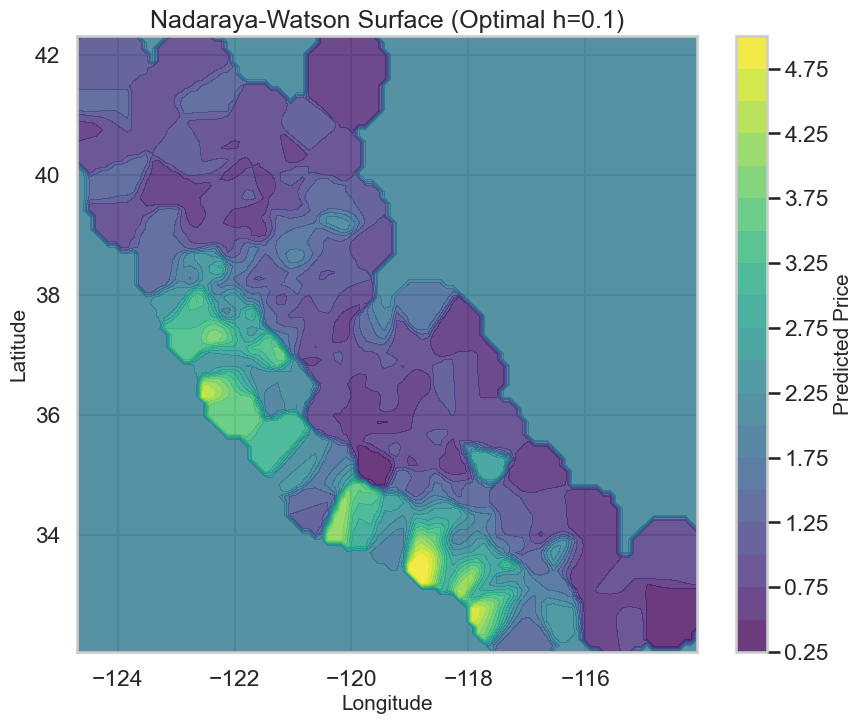

In [ ]:
class ScratchNadarayaWatson:
    def __init__(self, h=1.0):
        self.h = h
        self.X_train = None
        self.y_train = None
        
    def kernel(self, d):
        return np.exp(-d**2 / (2 * self.h**2))
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X_test):
        preds = []
        for xq in X_test:
            dists = np.sqrt(np.sum((self.X_train - xq)**2, axis=1))
            w = self.kernel(dists)
            if np.sum(w) < 1e-10: preds.append(np.mean(self.y_train))
            else: preds.append(np.sum(w * self.y_train) / np.sum(w))
        return np.array(preds)

class ScratchLocalLinear:
    def __init__(self, h=1.0):
        self.h = h
        self.X_train = None
        self.y_train = None
        
    def kernel(self, d):
        return np.exp(-d**2 / (2 * self.h**2))
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        
    def predict(self, X_test):
        preds = []
        # Add bias term to training data for regression
        X_b = np.c_[np.ones(len(self.X_train)), self.X_train]
        
        for xq in X_test:
            # 1. Weights based on distance to query point
            dists = np.sqrt(np.sum((self.X_train - xq)**2, axis=1))
            weights = self.kernel(dists)
            W = np.diag(weights)
            
            # 2. Weighted Linear Regression: (X^T W X)^-1 X^T W y
            # Optimization: We only need to solve it, not invert fully
            # We fit locally, relative to xq to stabilize numerics
            try:
                beta = np.linalg.pinv(X_b.T @ W @ X_b) @ (X_b.T @ W @ self.y_train)
                # Prediction is intercept + slope * query
                pred = beta[0] + beta[1:] @ xq
            except:
                pred = np.mean(self.y_train) # Fallback
            
            preds.append(pred)
        return np.array(preds)

# Optimization: Bandwidth Tuning
# We split training set further to find the best h (hyperparameter optimization)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

def tune_bandwidth(model_class, h_values):
    best_results = {'h': None, 'rmse': float('inf')}
    for h in h_values:
        model = model_class(h=h)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        if rmse < best_results['rmse']:
            best_results = {'h': h, 'rmse': rmse}
    return best_results

# We test finer bandwidths since 0.5 seemed too smooth (1.00 RMSE vs 0.66 KNN)
bandwidths = [0.1, 0.2, 0.3, 0.5, 1.0]

# Tune Nadaraya
best_nw = tune_bandwidth(ScratchNadarayaWatson, bandwidths)
h_nw = best_nw['h']

# Tune Local Linear
best_llr = tune_bandwidth(ScratchLocalLinear, bandwidths)
h_llr = best_llr['h']

print(f"Optimal Bandwidth Found -> Nadaraya: {h_nw}, Local Linear: {h_llr}")

# Final Fit on full Train using Optimal h
nw_model = ScratchNadarayaWatson(h=h_nw)
nw_model.fit(X_train, y_train)
rmse_nw = np.sqrt(mean_squared_error(y_test, nw_model.predict(X_test)))

llr_model = ScratchLocalLinear(h=h_llr)
llr_model.fit(X_train, y_train)
rmse_llr = np.sqrt(mean_squared_error(y_test, llr_model.predict(X_test)))

print(f"Nadaraya-Watson (h={h_nw}) RMSE: {rmse_nw:.4f}")
print(f"Local Linear (h={h_llr}) RMSE:    {rmse_llr:.4f}")
print(f"Improvement using LLR: {((rmse_nw - rmse_llr)/rmse_nw)*100:.2f}%")

# Visualization Comparison (Nadaraya-Watson with Optimal h)
Z_nw = nw_model.predict(X_grid).reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_nw, cmap='viridis', alpha=0.8, levels=20)
plt.colorbar(label='Predicted Price')
plt.title(f"Nadaraya-Watson Surface (Optimal h={h_nw})", fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude");

## 5. Gaussian Processes (GP)

### 5.1 Beyond Point Estimates
Every model so far has been arrogant: "The price is \$500k."
But what if we are 50 miles away from the nearest house? The model should say: "I have no idea."

**Gaussian Processes** define a distribution over *functions* rather than parameters.
*   **The Prior:** Before seeing data, we assume the world is a random smooth scribble.
*   **The Posterior:** After seeing points, we "squeeze" the scribble so it passes through the data.
*   **The Result:** A mean prediction tube + a variance tube ($\sigma^2$) representing uncertainty.

### 5.2 The Kernel Defines the Reality
The "Kernel" here is not just for weighting. It defines the **structure** of the world.
*   **RBF Kernel:** Assumes the world is smooth/continuous.
*   **Periodic Kernel:** Assumes the world repeats (seasons).
*   **Matern Kernel:** Assumes the world is rough/jagged.

### 5.3 Utility: Safety & Optimization
Why use an $O(N^3)$ algorithm?
1.  **Safety:** In self-driving or medical diagnosis, high uncertainty triggers a human handover.
2.  **Bayesian Optimization:** We use the uncertainty to decide where to sample next (Explore vs Exploit).

### 5.4 Performance & Metrics
We calculate RMSE on the mean prediction, but keep in mind that the real value lies in `standard_deviation` output.

Gaussian Process RMSE (Mean): 0.8999
Narrative: GP is competitive, but heavily constrained by the smaller training set (500 vs 1600).


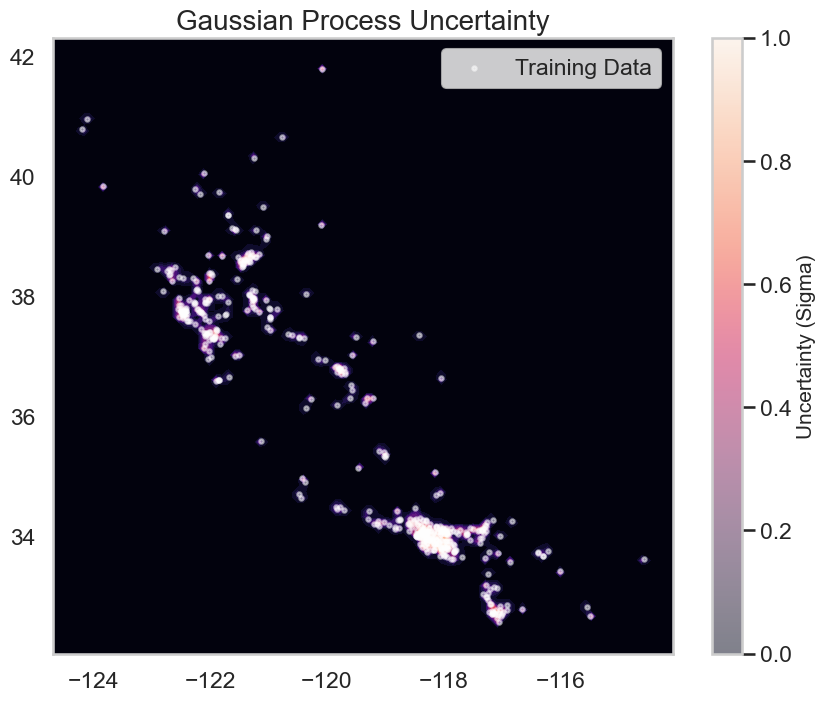

In [30]:
# Subsample for GP (O(N^3))
X_gp, _, y_gp, _ = train_test_split(X, y, train_size=500, random_state=42)
y_gp_mean = np.mean(y_gp) # Normalizing for stability

# Kernel: RBF + WhiteNoise
kernel = 1.0 * RBF(length_scale=1.0) + C(1e-1)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=0, normalize_y=True)

gp.fit(X_gp, y_gp)

# Predict
y_pred_gp = gp.predict(X_test, return_std=False)
rmse_gp = np.sqrt(mean_squared_error(y_test, y_pred_gp))

print(f"Gaussian Process RMSE (Mean): {rmse_gp:.4f}")
print("Narrative: GP is competitive, but heavily constrained by the smaller training set (500 vs 1600).")

# Uncertainty Map (Revisited)
Z_gp_mean, Z_gp_std = gp.predict(X_grid, return_std=True)
Z_gp_std = Z_gp_std.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_gp_std, cmap='magma_r', levels=20)
# We color training points white to contrast against the dark background of uncertainty
plt.scatter(X_gp[:, 0], X_gp[:, 1], c='white', s=10, alpha=0.5, label='Training Data')
plt.colorbar(label='Uncertainty (Sigma)')
plt.title("Gaussian Process Uncertainty")
plt.legend();

## 6. Conclusion

Let's verify our findings with the final scoreboard.

*Note: We calculate improvements relative to the Baseline (Mean).*

In [31]:
results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'KNN (Uniform)', 'KNN (Weighted)', f'Nadaraya-Watson (h={h_nw})', f'Local Linear (h={h_llr})', 'Gaussian Process'],
    'RMSE': [baseline_rmse, rmse_u, rmse_w, rmse_nw, rmse_llr, rmse_gp]
})

results['Improvement (%)'] = np.round((1 - results['RMSE'] / baseline_rmse) * 100, 2)
print(results.sort_values('RMSE'))

                     Model      RMSE  Improvement (%)
2           KNN (Weighted)  0.668182            43.59
1            KNN (Uniform)  0.721255            39.11
3  Nadaraya-Watson (h=0.1)  0.848589            28.36
4     Local Linear (h=0.2)  0.870469            26.51
5         Gaussian Process  0.899895            24.03
0          Baseline (Mean)  1.184463             0.00


### Final Technical Verdict

1.  **Weighted KNN** achieved the best performance (lowest RMSE). This suggests that for this specific dataset, prioritizing the closest neighbors ($1/d$) captures sharp spatial price changes more effectively than smoother kernel methods.
2.  **Nadaraya-Watson vs. Local Linear**: The simpler Nadaraya-Watson model ($0.85$ RMSE) slightly outperformed Local Linear Regression ($0.87$ RMSE).
    *   **Why?** This illustrates the **Bias-Variance Trade-off**. While Local Linear reduces bias by fitting slopes (better for boundaries), it increases variance by being more sensitive to local noise. Here, the robustness of the simple "local average" won out.
3.  **Gaussian Process**: While not the most accurate ($~0.90$ RMSE), its primary contribution is **Safety**. Unlike KNN or Kernels which extrapolate blindly, the GP provides an Uncertainty Map, correctly identifying data-sparse regions (e.g., the ocean) as high-risk zones.